In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("C:/Users/Administrator/PythonProjects/abfluss_queich")

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from database.queries import load_discharge_data, load_inference_data, load_precip_observation_data, load_precip_forecast_data
from jobs.inference.ingest_inference import merge_data, create_inference_features
from jobs.discharge.preprocessing.filtering import hampel_filter
from model.dataset import TimeSeriesDataset
from model.build_model import model
from model.inference import run_inference

In [ ]:
discharge = load_discharge_data(days=14)
discharge = hampel_filter(discharge)

precip_observation = load_precip_observation_data(days=14)
precip_forecast = load_precip_forecast_data()

dfs = [discharge, precip_observation]

merged = merge_data(dfs=dfs)
merged["precip_mean"] = merged["precip_mean"].ffill()

merged["discharge"] = merged["discharge"].rolling(window="3h").mean()

features = create_inference_features(df=merged)

# merged["discharge"] = merged["discharge"].ewm(span=9).mean()

## Recursive

In [72]:
from collections.abc import Sequence
import pandas as pd


def recursive_forecast(
    history: pd.DataFrame,
    steps: int,
) -> pd.DataFrame:

    history = history.copy()
    

    predictions = []

    for _ in range(steps):

        
        # Create latest features
        features = create_inference_features(history)

        # Predict next timestep
        prediction = run_inference(features)[0]

        # Next timestamp
        next_idx = history.index[-1] + pd.Timedelta(minutes=15)

        # Create new row
        next_row = history.iloc[-1].copy()

        # Replace discharge with prediction
        next_row["discharge"] = prediction

        # Update timestamp
        next_row.name = next_idx

        # Append
        history = pd.concat(
            [history, next_row.to_frame().T]
        )

        predictions.append(
            {
                "timestamp": next_idx,
                "prediction": prediction,
            }
        )

    return pd.DataFrame(predictions)

In [73]:
recursive_preds = recursive_forecast(
    history=merged, 
    steps=4*24
    )
recursive_preds = recursive_preds.set_index("timestamp")

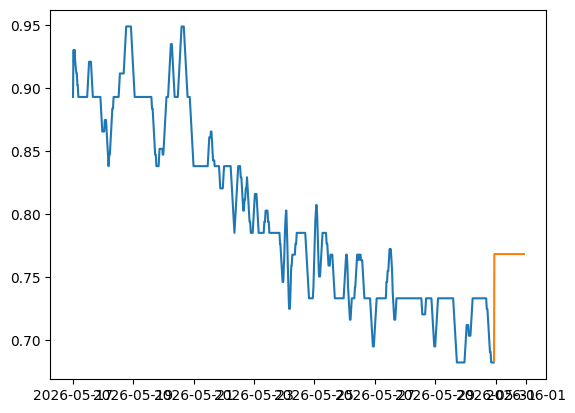

In [74]:
fig, ax = plt.subplots()

ax.plot(merged["discharge"])
# ax.plot(recursive_preds)
ax.plot(recursive_preds + discharge.iloc[-1].values)

plt.show()

## Multimodal

In [75]:
from model.features import create_training_features
from model.dataset import TimeSeriesDataset
from model.build_model import model

In [266]:
discharge = load_discharge_data(days=14)
discharge = hampel_filter(discharge)

precip_observation = load_precip_observation_data(days=14)
precip_forecast = load_precip_forecast_data()


dfs = [discharge, precip_observation]

merged = merge_data(dfs=dfs)
merged["precip_mean"] = merged["precip_mean"].ffill()
merged["discharge"] = merged["discharge"].rolling(window="12h").mean()

In [276]:
inference_steps = {
    "15min": 1,
    "30min": 2,
    "45min": 3,
    "60min": 4,
    
    "120min": 8,
    "180min": 12,
    "240min": 16,
    "300min": 20,
    "360min": 24,
    }

print(inference_steps)

features = {}

for time, step in inference_steps.items():
    
    df_feature = create_training_features(df=merged, horizon=step)

    features[time] = df_feature

{'15min': 1, '30min': 2, '45min': 3, '60min': 4, '120min': 8, '180min': 12, '240min': 16, '300min': 20, '360min': 24}


In [277]:
def train_and_save_model(df, timestep):
    # Create dataset
    dataset = TimeSeriesDataset(df)

    train_dataset, val_dataset, test_dataset = (
        dataset.create_datasets()
    )


    # Fit model
    model.fit(
        train_dataset[0], 
        train_dataset[1],
        eval_set=[(val_dataset[0], val_dataset[1])],
    )


    # Save model
    save_dir = Path("models/multimodel")
    save_dir.mkdir(exist_ok=True, parents=True)
    
    model_name = f"xgb_model_{timestep}.json"
    save_path = save_dir / model_name

    model.save_model(save_path)
    print(f"Saved model '{model_name}' to {save_path}")
    
    return test_dataset

In [278]:
test_datasets = {}

for timestep, df in features.items():
    test_dataset = train_and_save_model(
        df=df,
        timestep=timestep
    )
    
    test_datasets[timestep] = test_dataset

Train size: 902
Val size: 257
Test size: 130
[0]	validation_0-rmse:0.00066
[1]	validation_0-rmse:0.00065
[2]	validation_0-rmse:0.00065
[3]	validation_0-rmse:0.00065
[4]	validation_0-rmse:0.00065
[5]	validation_0-rmse:0.00065
[6]	validation_0-rmse:0.00065
[7]	validation_0-rmse:0.00065
[8]	validation_0-rmse:0.00065
[9]	validation_0-rmse:0.00065
[10]	validation_0-rmse:0.00065
[11]	validation_0-rmse:0.00065
[12]	validation_0-rmse:0.00065
[13]	validation_0-rmse:0.00065
[14]	validation_0-rmse:0.00065
[15]	validation_0-rmse:0.00065
[16]	validation_0-rmse:0.00065
[17]	validation_0-rmse:0.00065
[18]	validation_0-rmse:0.00065
[19]	validation_0-rmse:0.00065
[20]	validation_0-rmse:0.00064
[21]	validation_0-rmse:0.00064
[22]	validation_0-rmse:0.00064
[23]	validation_0-rmse:0.00064
[24]	validation_0-rmse:0.00064
[25]	validation_0-rmse:0.00064
[26]	validation_0-rmse:0.00064
[27]	validation_0-rmse:0.00064
[28]	validation_0-rmse:0.00064
[29]	validation_0-rmse:0.00064
[30]	validation_0-rmse:0.00064
[31]

In [279]:
from xgboost import XGBRegressor

def load_model(path: str | Path):
    model = XGBRegressor()
    model.load_model(path)
    
    return model


def run_inference(
    df: pd.DataFrame,
    model_path: str | Path
    ):
    model = load_model(path=model_path)
    
    return model.predict(df)


def get_timestep_str(path: str | Path) -> str:
    path = Path(path)
    
    stem = path.stem
    _, _, timestep = stem.split("_")
    
    return timestep

In [280]:
model_dir = Path("C:/Users/Administrator/PythonProjects/abfluss_queich/models/multimodel")
model_paths = {get_timestep_str(p): p for p in model_dir.glob("*.json")}

In [281]:
features = create_inference_features(df=merged)

inferences = {}

for model_path_items, test_dataset in zip(model_paths.items(), features):
    timestep, model_path = model_path_items
    
    inference = run_inference(
        df=features,
        model_path=model_path
        )
    
    inferences[timestep] = inference

In [282]:
def create_preds_df(
    inference: dict,
    history: pd.DataFrame
    ) -> pd.DataFrame:
    
    last_index = history.index.max()
    last_discharge = history.sort_index().tail(1).discharge.values
    
    preds = pd.DataFrame.from_dict(data=inference, orient="index")

    preds.index = pd.to_timedelta(preds.index) + pd.Timestamp(last_index)
    # preds.index = pd.to_timedelta(preds.index) + pd.Timestamp(last_index.values[0])

    preds = preds + last_discharge
    
    return preds
    

In [283]:
preds = create_preds_df(inference=inferences, history=merged)
preds = preds.sort_index()
preds

,0
2026-05-30 23:45:00,0.705305
2026-05-31 00:00:00,0.705225
2026-05-31 00:15:00,0.704990
2026-05-31 00:30:00,0.704289
2026-05-31 01:30:00,0.701487
2026-05-31 02:30:00,0.702908
2026-05-31 03:30:00,0.701337
2026-05-31 04:30:00,0.703228
2026-05-31 05:30:00,0.704173


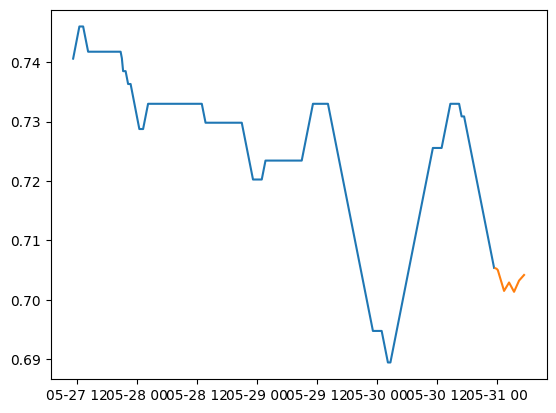

In [284]:
fig, ax = plt.subplots()

# ax.plot(merged["discharge"])
ax.plot(merged["discharge"][1000:])
ax.plot(preds)

plt.show()